In [25]:
import math
import torch
import random
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision
from torchvision import transforms
!pip install matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys, os
from contextlib import redirect_stdout
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix,
                             classification_report, cohen_kappa_score, roc_curve)
import time
import os
from PIL import Image
from collections import Counter
%pip install seaborn
import seaborn as sns
from matplotlib.cm import get_cmap
%pip install torchinfo ptflops
from torchinfo import summary
from ptflops import get_model_complexity_info

%pip install medmnist
from medmnist import PneumoniaMNIST

%pip install causal-conv1d
%pip install mamba-ssm
from einops import rearrange

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached causal_conv1d-1.6.1.tar.gz (29 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for causal-conv1d (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [119 lines of output]
      /tmp/pip-build-env-vf7iub11/overlay/lib/python3.12/site-packages/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of the 'bdist_wheel' command, and will be removed in a future release. Please update to setuptools v70.1 or later which contains an integrated version of this command.
        warn(
      /tmp/pip-build-env-vf7iub11/overlay/lib/python3.12/site-packages/torch/_subclasses/functional_ten

In [26]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # cuDNN stable settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
try:
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn
    _mamba_available = True
    print("successded")
except ImportError:
    _mamba_available = False
    print("Couldn't import mamba")



class SS2D(nn.Module):
    """
    Selective Scan 2D - Core Vision Mamba component with 4-directional scanning
    """
    def __init__(
        self,
        d_model,
        d_state=16,
        d_conv=3,
        expand=2,
        dt_rank="auto",
        dt_min=0.001,
        dt_max=0.1,
        dt_init="random",
        dt_scale=1.0,
        dt_init_floor=1e-4,
        dropout=0.,
        conv_bias=True,
        bias=False,
        device=None,
        dtype=None,
    ):
        factory_kwargs = {"device": device, "dtype": dtype}
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(self.expand * self.d_model)
        self.dt_rank = math.ceil(self.d_model / 16) if dt_rank == "auto" else dt_rank

        # Input projection (projects to 2x for x and z)
        self.in_proj = nn.Linear(self.d_model, self.d_inner * 2, bias=bias, **factory_kwargs)
        
        # Depthwise convolution for local features
        self.conv2d = nn.Conv2d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            groups=self.d_inner,
            bias=conv_bias,
            kernel_size=d_conv,
            padding=(d_conv - 1) // 2,
            **factory_kwargs,
        )
        self.act = nn.SiLU()

        # x_proj projects to (dt_rank + d_state * 2) for each of 4 directions
        self.x_proj = nn.ModuleList([
            nn.Linear(self.d_inner, (self.dt_rank + self.d_state * 2), bias=False, **factory_kwargs)
            for _ in range(4)
        ])
        self.x_proj_weight = nn.Parameter(torch.stack([t.weight for t in self.x_proj], dim=0))
        del self.x_proj

        # dt_proj projects from dt_rank to d_inner for each direction
        self.dt_projs = nn.ModuleList([
            self.dt_init(self.dt_rank, self.d_inner, dt_scale, dt_init, dt_min, dt_max, dt_init_floor, **factory_kwargs)
            for _ in range(4)
        ])
        self.dt_projs_weight = nn.Parameter(torch.stack([t.weight for t in self.dt_projs], dim=0))
        self.dt_projs_bias = nn.Parameter(torch.stack([t.bias for t in self.dt_projs], dim=0))
        del self.dt_projs
        
        # State space parameters
        self.A_logs = self.A_log_init(self.d_state, self.d_inner, copies=4, merge=True)
        self.Ds = self.D_init(self.d_inner, copies=4, merge=True)

        # Output normalization and projection
        self.out_norm = nn.LayerNorm(self.d_inner)
        self.out_proj = nn.Linear(self.d_inner, self.d_model, bias=bias, **factory_kwargs)
        self.dropout = nn.Dropout(dropout) if dropout > 0. else None

    @staticmethod
    def dt_init(dt_rank, d_inner, dt_scale=1.0, dt_init="random", dt_min=0.001, dt_max=0.1, dt_init_floor=1e-4, **factory_kwargs):
        dt_proj = nn.Linear(dt_rank, d_inner, bias=True, **factory_kwargs)

        dt_init_std = dt_rank**-0.5 * dt_scale
        if dt_init == "constant":
            nn.init.constant_(dt_proj.weight, dt_init_std)
        elif dt_init == "random":
            nn.init.uniform_(dt_proj.weight, -dt_init_std, dt_init_std)
        else:
            raise NotImplementedError

        dt = torch.exp(
            torch.rand(d_inner, **factory_kwargs) * (math.log(dt_max) - math.log(dt_min))
            + math.log(dt_min)
        ).clamp(min=dt_init_floor)
        inv_dt = dt + torch.log(-torch.expm1(-dt))
        with torch.no_grad():
            dt_proj.bias.copy_(inv_dt)
        dt_proj.bias._no_reinit = True
        
        return dt_proj

    @staticmethod
    def A_log_init(d_state, d_inner, copies=1, device=None, merge=True):
        A = torch.arange(1, d_state + 1, dtype=torch.float32, device=device).view(1, -1).repeat(d_inner, 1)
        A_log = torch.log(A)
        if copies > 1:
            A_log = A_log.unsqueeze(0).repeat(copies, 1, 1)
            if merge:
                A_log = A_log.flatten(0, 1)
        A_log = nn.Parameter(A_log)
        A_log._no_weight_decay = True
        return A_log

    @staticmethod
    def D_init(d_inner, copies=1, device=None, merge=True):
        D = torch.ones(d_inner, device=device)
        if copies > 1:
            D = D.unsqueeze(0).repeat(copies, 1)
            if merge:
                D = D.flatten(0, 1)
        D = nn.Parameter(D)
        D._no_weight_decay = True
        return D

    def forward_core(self, x: torch.Tensor):
        """
        Core selective scan with 4-directional scanning
        x: [B, C, H, W]
        """
        B, C, H, W = x.shape
        L = H * W
        K = 4  # 4 directions

        # Create 4 scanning directions
        # Direction 0: row-wise (H, W) - left to right
        # Direction 1: column-wise (W, H) - top to bottom  
        # Direction 2: reverse row-wise - right to left
        # Direction 3: reverse column-wise - bottom to top
        x_hwwh = torch.stack([
            x.view(B, -1, L),  # [B, C, H*W]
            torch.transpose(x, dim0=2, dim1=3).contiguous().view(B, -1, L)  # [B, C, W*H]
        ], dim=1).view(B, 2, -1, L)
        
        xs = torch.cat([x_hwwh, torch.flip(x_hwwh, dims=[-1])], dim=1)  # [B, K=4, C, L]

        # Project to dt, B, C parameters for each direction
        x_dbl = torch.einsum("b k d l, k c d -> b k c l", xs.view(B, K, -1, L), self.x_proj_weight)
        dts, Bs, Cs = torch.split(x_dbl, [self.dt_rank, self.d_state, self.d_state], dim=2)
        dts = torch.einsum("b k r l, k d r -> b k d l", dts.view(B, K, -1, L), self.dt_projs_weight)

        # Prepare for selective scan
        xs = xs.float().view(B, -1, L)  # [B, K*C, L]
        dts = dts.contiguous().float().view(B, -1, L)  # [B, K*C, L]
        Bs = Bs.float().view(B, K, -1, L)  # [B, K, d_state, L]
        Cs = Cs.float().view(B, K, -1, L)  # [B, K, d_state, L]
        Ds = self.Ds.float().view(-1)  # [K*C]
        As = -torch.exp(self.A_logs.float()).view(-1, self.d_state)  # [K*C, d_state]
        dt_projs_bias = self.dt_projs_bias.float().view(-1)  # [K*C]

        # Selective scan
        out_y = selective_scan_fn(
            xs, dts, 
            As, Bs, Cs, Ds, z=None,
            delta_bias=dt_projs_bias,
            delta_softplus=True,
            return_last_state=False,
        ).view(B, K, -1, L)

        # Merge 4 directions
        # Reverse the flipped directions back
        inv_y = torch.flip(out_y[:, 2:4], dims=[-1]).view(B, 2, -1, L)
        
        # Transpose back for direction 1 and 3 (column-wise scans)
        wh_y = torch.transpose(out_y[:, 1].view(B, -1, W, H), dim0=2, dim1=3).contiguous().view(B, -1, L)
        invwh_y = torch.transpose(inv_y[:, 1].view(B, -1, W, H), dim0=2, dim1=3).contiguous().view(B, -1, L)

        # Sum all 4 directions
        return out_y[:, 0] + inv_y[:, 0] + wh_y + invwh_y

    def forward(self, x: torch.Tensor):
        """
        x: [B, L, D] where L = H*W (flattened spatial dimensions)
        """
        B, L, D = x.shape
        
        # Calculate H, W from L (assuming square)
        H = W = int(math.sqrt(L))
        assert H * W == L, f"Sequence length {L} is not a perfect square"

        # Project input to 2x dimension and split into x and z
        xz = self.in_proj(x)  # [B, L, 2*d_inner]
        x, z = xz.chunk(2, dim=-1)  # Each [B, L, d_inner]

        # Reshape to 2D for convolution and scanning
        x = x.permute(0, 2, 1).contiguous().view(B, self.d_inner, H, W)  # [B, d_inner, H, W]
        
        # Apply depthwise convolution
        x = self.act(self.conv2d(x))  # [B, d_inner, H, W]
        
        # 4-directional selective scan
        y = self.forward_core(x)  # [B, d_inner, L]
        assert y.dtype == torch.float
        
        # Reshape back to [B, L, d_inner]
        y = y.transpose(1, 2).contiguous()  # [B, L, d_inner]
        
        # Normalize and gate with z
        y = self.out_norm(y)
        z = z.view(B, L, self.d_inner)
        y = y * F.silu(z)
        
        # Project back to d_model
        out = self.out_proj(y)
        if self.dropout is not None:
            out = self.dropout(out)
        
        return out

class VisionMambaBlock(nn.Module):
    """
    Vision Mamba block with SS2D and MLP
    """
    def __init__(self, embed_dim: int, d_state: int = 16, d_conv: int = 3,
                 expand: int = 2, dropout: float = 0.15):
        super().__init__()

        if _mamba_available:
            self.mixer = SS2D(
                d_model=embed_dim,
                d_state=d_state,
                d_conv=d_conv,
                expand=expand,
                dropout=dropout
            )
        else:
            # Fallback to simple linear block
            print("Warning: Using fallback linear mixer instead of SS2D")
            self.mixer = nn.Sequential(
                nn.Linear(embed_dim, embed_dim * expand),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(embed_dim * expand, embed_dim),
                nn.Dropout(dropout)
            )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )

        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: [B, L, D]
        """
        # SS2D path with residual
        x = x + self.drop(self.mixer(self.norm1(x)))
        # MLP path with residual
        x = x + self.mlp(self.norm2(x))
        return x


class DropBlock2D(nn.Module):
    def __init__(self, block_size=5, drop_prob=0.15):
        super().__init__()
        self.block_size = block_size
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.:
            return x
        gamma = self.drop_prob / (self.block_size ** 2)
        mask = torch.bernoulli(torch.ones_like(x[:, 0, :, :]) * gamma)
        mask = F.max_pool2d(mask.unsqueeze(1), self.block_size,
                            stride=1, padding=self.block_size // 2)
        mask = 1 - mask.squeeze(1)
        x = x * mask.unsqueeze(1)
        return x


class PatchEmbedding(nn.Module):
    def __init__(self, in_chans=64, embed_dim=768, patch_size=4):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.patch_size = patch_size
        
    def forward(self, x):
        x = self.proj(x)  # [B, embed_dim, H', W']
        x = x.flatten(2)  # [B, embed_dim, H'*W']
        x = x.transpose(1, 2)  # [B, H'*W', embed_dim]
        return x


class TokenMerger(nn.Module):
    def __init__(self, embed_dim, out_grid_size):
        """
        out_grid_size: the H (and W) of the output grid.
        merger1: out_grid_size=3  →  3x3 = 9 tokens
        merger2: out_grid_size=2  →  2x2 = 4 tokens
        AdaptiveAvgPool2d always hits the target size exactly,
        regardless of input size. No edge-case math needed.
        """
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(out_grid_size)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B, L, D = x.shape
        H = W = int(math.sqrt(L))
        x = x.transpose(1, 2).reshape(B, D, H, W)  # [B, D, H, W]
        x = self.pool(x)                             # [B, D, out_grid, out_grid]
        x = x.flatten(2).transpose(1, 2)            # [B, out_grid^2, D]
        x = self.norm(self.proj(x))
        return x



class FocalLoss(nn.Module):
    def __init__(self, gamma=2, weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
    def forward(self, input, target):
        logp = F.log_softmax(input, dim=1)
        pt = torch.exp(logp)
        logp = (1 - pt) ** self.gamma * logp
        loss = F.nll_loss(logp, target, weight=self.weight, reduction=self.reduction)
        return loss



class VisionMambaModel(nn.Module):
    def __init__(self, num_classes=11, embed_dim=768, num_layers=6, d_state=16,
                 dropblock_prob=0.15, input_channels=1):
        super().__init__()

        # CNN stem (unchanged)
        self.cnn_stem = nn.Sequential(
            # 224 -> 112
            nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            # 112 -> 56
            nn.AvgPool2d(kernel_size=3, stride=2, padding=1),
            DropBlock2D(block_size=5, drop_prob=dropblock_prob),
            # 56 -> 28
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
        )
        
        self.patch_embed = PatchEmbedding(in_chans=64, embed_dim=embed_dim, patch_size=4)

        # Learnable 2D positional embedding grid 
        self.pos_embed = nn.Parameter(torch.zeros(1, embed_dim, 7, 7))
        nn.init.normal_(self.pos_embed, std=0.02)
        self.pos_drop = nn.Dropout(0.0)

        # Vision Mamba blocks — kept as individual named attributes for skip connection access
        self.block1 = VisionMambaBlock(embed_dim, d_state=d_state, d_conv=3, expand=2, dropout=0.15)
        self.block2 = VisionMambaBlock(embed_dim, d_state=d_state, d_conv=3, expand=2, dropout=0.15)
        self.block3 = VisionMambaBlock(embed_dim, d_state=d_state, d_conv=3, expand=2, dropout=0.15)

        # merger1: 49 tokens (7x7) → 9 tokens (3x3)
        self.merger1 = TokenMerger(embed_dim, out_grid_size=3)
        # merger2:  9 tokens (3x3) → 4 tokens (2x2)
        self.merger2 = TokenMerger(embed_dim, out_grid_size=2)

        # Pooling — kept identical to your existing setup
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.adaptive_max_pool = nn.AdaptiveMaxPool1d(1)

        # Main classifier (unchanged)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # CNN stem — unchanged
        x = self.cnn_stem(x)          # [B, 64, 28, 28]
        b, c, h, w = x.shape

        # Patch embedding — unchanged
        patches = self.patch_embed(x) # [B, 49, embed_dim]

        # Positional encoding — unchanged
        gh = h // self.patch_embed.patch_size
        gw = w // self.patch_embed.patch_size
        pos = self.pos_embed
        if pos.shape[2] != gh or pos.shape[3] != gw:
            pos = F.interpolate(pos, size=(gh, gw), mode='bicubic', align_corners=False)
        pos = pos.flatten(2).transpose(1, 2)   # [1, 49, embed_dim]
        patches = self.pos_drop(patches + pos)

        # ── HIERARCHICAL TOKEN COMPRESSION ──────────────────────────────
        # Block 1: fine-grained local detail at full 49-token resolution
        x1 = self.block1(patches)              # [B, 49, D]  ← save as skip

        # Compress: 49 tokens (7x7) → 9 tokens (3x3)
        x2_in = self.merger1(x1)              # [B, 9, D]

        # Block 2: mid-scale structure at 9-token resolution
        x2 = self.block2(x2_in)              # [B, 9, D]

        # Compress: 9 tokens (3x3) → 4 tokens (2x2)
        x3_in = self.merger2(x2)              # [B, 4, D]

        # Block 3: global context at 4-token resolution
        x3 = self.block3(x3_in)              # [B, 4, D]
        # ────────────────────────────────────────────────────────────────

        # Multi-scale pooling: global (Block 3) + local skip (Block 1)
        # Global representation from 4 coarse tokens
        global_avg = self.global_avg_pool(x3.transpose(1, 2)).squeeze(-1)   # [B, D]
        global_max = self.adaptive_max_pool(x3.transpose(1, 2)).squeeze(-1) # [B, D]
        global_rep = 0.5 * (global_avg + global_max)

        # Local representation from 49 fine tokens (skip connection from Block 1)
        local_avg = self.global_avg_pool(x1.transpose(1, 2)).squeeze(-1)    # [B, D]
        local_max = self.adaptive_max_pool(x1.transpose(1, 2)).squeeze(-1)  # [B, D]
        local_rep = 0.5 * (local_avg + local_max)

        # Fuse global and local — equal weight
        pooled = 0.5 * (global_rep + local_rep)

        logits = self.classifier(pooled)
        return logits

successded


In [28]:

def calculate_metrics(y_true, y_pred, y_prob, num_classes):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    specificity = np.mean(specificity_per_class)
    auc_scores = []
    for i in range(num_classes):
        y_true_binary = (y_true == i).astype(int)
        y_prob_binary = y_prob[:, i]
        try:
            auc_scores.append(roc_auc_score(y_true_binary, y_prob_binary))
        except Exception:
            auc_scores.append(np.nan)
    auc_roc = np.nanmean(auc_scores)
    kappa = cohen_kappa_score(y_true, y_pred)
    dice_scores = []
    for i in range(num_classes):
        y_true_binary = (y_true == i).astype(int)
        y_pred_binary = (y_pred == i).astype(int)
        intersection = np.sum(y_true_binary * y_pred_binary)
        dice = 2 * intersection / (np.sum(y_true_binary) + np.sum(y_pred_binary)) if (np.sum(y_true_binary) + np.sum(y_pred_binary)) > 0 else 0
        dice_scores.append(dice)
    dice_coeff = np.mean(dice_scores)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'cohen_kappa': kappa,
        'dice_coefficient': dice_coeff
    }

def get_loss_fn(use_focal=False):
    if use_focal:
        return FocalLoss(gamma=2)
    else:
        return nn.CrossEntropyLoss(label_smoothing=0.1)


def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label='Training Loss', color='#FF6B6B', linewidth=2)
    ax1.plot(val_losses, label='Validation Loss', color='#4ECDC4', linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(train_accs, label='Training Accuracy', color='#45B7D1', linewidth=2)
    ax2.plot(val_accs, label='Validation Accuracy', color='#96CEB4', linewidth=2)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



def train_model(model, train_loader, val_loader, device, num_epochs=100, lr=1e-4, use_focal=False, early_stop_patience=30):
    criterion = get_loss_fn(use_focal)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    best_epoch = 0
    
    es = None
    if early_stop_patience is not None:
        es = EarlyStopping(patience=early_stop_patience, mode='max')
    
    total_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(targets).sum().item()
        
        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        scheduler.step()
        
        # Calculate metrics
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_acc = 100. * train_correct / train_total
        val_acc = 100. * val_correct / val_total
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_256_hymacnetv2_Pneumonia.pth')
            print(f" New best model Val Acc: {val_acc:.2f}%")
        
        epoch_end_time = time.time()
        epoch_elapsed = epoch_end_time - epoch_start_time
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'Epoch Time: {epoch_elapsed:.2f} sec')
        print('-' * 50)
        
        # Early stopping
        if es is not None:
            es(val_acc)
            if es.stop:
                print(f"Early stopping at epoch {epoch+1} "
                      f"(no val-acc improvement for {es.patience} epochs).")
                break
    
    total_end_time = time.time()
    total_elapsed = total_end_time - total_start_time
    
    print(f"\nTotal Training Time: {total_elapsed/60:.2f} minutes")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch+1})")
    
    return train_losses, val_losses, train_accs, val_accs


def evaluate_model(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_targets = []
    all_probabilities = []
    inference_times = []
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            start_time = time.time()
            outputs = model(data)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end_time = time.time()
            inference_times.append((end_time - start_time) / data.size(0))
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    all_probabilities = np.array(all_probabilities)
    avg_inference_time = np.mean(inference_times) * 1000
    return all_targets, all_predictions, all_probabilities, avg_inference_time

def load_model_weights(model, checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location='cpu')
    model_is_parallel = isinstance(model, nn.DataParallel)
    ckpt_is_parallel = list(state_dict.keys())[0].startswith("module.")

    print(f"Model is DataParallel: {model_is_parallel}, Checkpoint has 'module.': {ckpt_is_parallel}")

    if model_is_parallel and not ckpt_is_parallel:
        model.module.load_state_dict(state_dict)
    elif not model_is_parallel and ckpt_is_parallel:
        from collections import OrderedDict
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] if k.startswith("module.") else k
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(state_dict)
    return model

def print_model_summary(model, input_size=(1, 3, 224, 224), device='cuda'):
    if isinstance(model, nn.DataParallel):
        model_to_summarize = model.module
    else:
        model_to_summarize = model
    print(summary(model_to_summarize, input_size=input_size, device=device))

def print_model_flops(model, input_res=(3, 224, 224)):
    if isinstance(model, nn.DataParallel):
        model_to_measure = model.module
    else:
        model_to_measure = model
    
   
    macs, params = get_model_complexity_info(
        model_to_measure,
        input_res,
        as_strings=False,
        print_per_layer_stat=True,   
        verbose=True                 
    )

    gflops = macs / 1e9
    gparams = params / 1e6
    print("="*60)
    print(f"Total MACs   : {macs:,} ({gflops:.2f} GMACs)")
    print(f"Total Params : {params:,} ({gparams:.2f} Million)")
    print("="*60)
# ───────────────────────────────────────────────────────────────────────
class EarlyStopping:

    def __init__(self, patience=50, mode='max', delta=0.0):
        self.patience = patience
        self.mode     = mode
        self.delta    = delta
        self.best     = None
        self.count    = 0
        self.stop     = False

    def __call__(self, current):
        if self.best is None:
            self.best = current
            return
        if ((self.mode == 'max' and current >  self.best + self.delta) or
            (self.mode == 'min' and current <  self.best - self.delta)):
            self.best  = current
            self.count = 0
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True

# ======================= mean/std utility ==========================
from torchvision.datasets import ImageFolder

def compute_mean_std(dataset, batch_size=64, num_workers=2):

    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=num_workers, pin_memory=True)
    
    
    first_batch = next(iter(loader))
    images, _ = first_batch
    num_channels = images.size(1)  # channel dimension
    
    print(f"Detected {num_channels} channel(s) in images")
    
    mean = torch.zeros(num_channels)
    std = torch.zeros(num_channels)
    total = 0
    
    for images, _ in loader:
        b = images.size(0)
        images = images.view(b, images.size(1), -1)  # [B, C, H*W]
        mean += images.mean(dim=2).sum(dim=0)
        std += images.std(dim=2).sum(dim=0)
        total += b
    
    mean /= total
    std /= total
    return mean.tolist(), std.tolist()
    

# For MEDMNIST datasets

def get_medmnist_labels(dataset):
    try:
        arr = dataset.dataset.labels  # shape (N, 1) or (N,)
        labels = np.array(arr).squeeze().astype(int).tolist()
        return labels
    except Exception:
        # Fallback: iterate (slower)
        labels = []
        for _, y in dataset:
            labels.append(int(y))
        return labels

def plot_class_counts(counts, class_names, title="Class Distribution"):
    idxs = list(range(len(class_names)))
    plt.figure(figsize=(10, 6))
    plt.bar(idxs, [counts.get(i, 0) for i in idxs], edgecolor="black", alpha=0.85)
    plt.xticks(idxs, class_names, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(title, fontweight="bold")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def build_weighted_sampler(labels, num_classes, target_per_class=None):

    counts = Counter(labels)
    max_count = max(counts.values())
    if target_per_class is None:
        target_per_class = max_count

   
    class_weights = {c: (1.0 / counts[c]) if counts[c] > 0 else 0.0 for c in range(num_classes)}
    sample_weights = np.array([class_weights[l] for l in labels], dtype=np.float32)

    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=target_per_class * num_classes,  
        replacement=True
    )
    effective = target_per_class * num_classes
    return sampler, effective, counts, max_count


In [29]:
os.makedirs("logs_v2", exist_ok=True)
os.makedirs("v2", exist_ok=True)

log_path = os.path.join("logs_v2", "Pneumonia_run_log_256_v2.txt")

class PneumoniaMNISTWrapper(torch.utils.data.Dataset):
    def __init__(self, split, transform=None, download=True, size=224):
       
        self.dataset = PneumoniaMNIST(split=split, transform=transform, download=download, size=size)
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, target = self.dataset[idx]
        if isinstance(target, torch.Tensor):
            if target.dim() > 0:
                target = target.item() if target.numel() == 1 else target.squeeze().long()
            else:
                target = target.item()
        elif isinstance(target, np.ndarray):
            target = int(target.squeeze()) if target.size == 1 else int(target)
        return image, int(target)

100%|██████████| 214M/214M [00:20<00:00, 10.6MB/s] 


VisionMambaModel(
  3.15 M, 85.921% Params, 249.68 MMac, 99.193% MACs, 
  (cnn_stem): Sequential(
    77.25 k, 2.106% Params, 100.65 MMac, 39.987% MACs, 
    (0): Conv2d(3.14 k, 0.086% Params, 39.34 MMac, 15.628% MACs, 1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(128, 0.003% Params, 1.61 MMac, 0.638% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(0, 0.000% Params, 802.82 KMac, 0.319% MACs, approximate='none')
    (3): AvgPool2d(0, 0.000% Params, 802.82 KMac, 0.319% MACs, kernel_size=3, stride=2, padding=1)
    (4): DropBlock2D(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (5): Conv2d(36.86 k, 1.005% Params, 28.9 MMac, 11.482% MACs, 64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, 0.003% Params, 100.35 KMac, 0.040% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): GELU(0, 0.000% Params, 50.18 KMac, 0.020% MACs, approximat

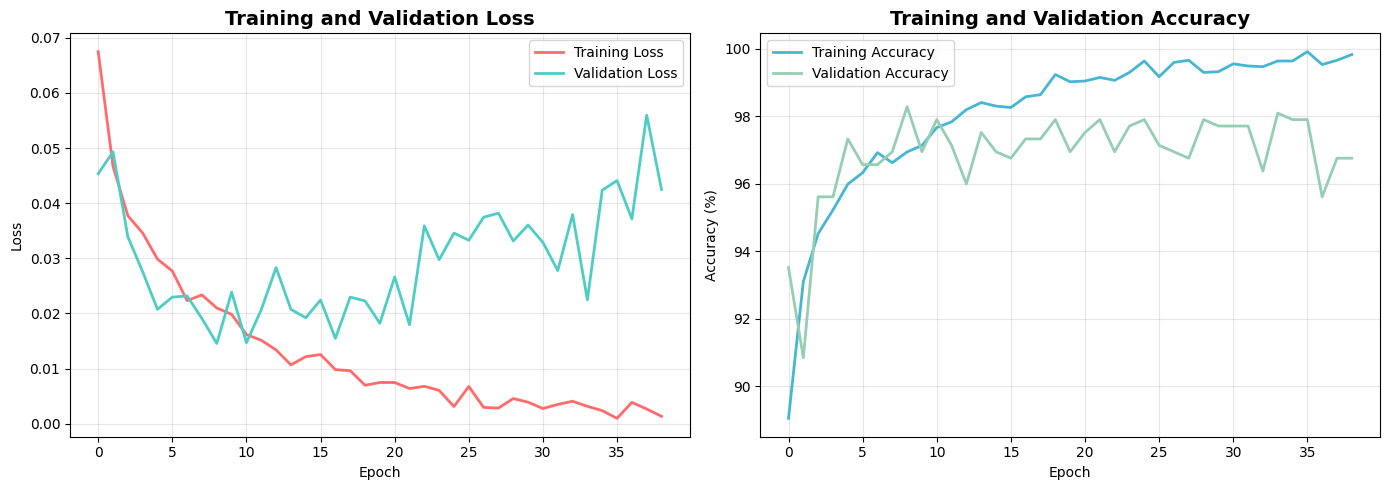

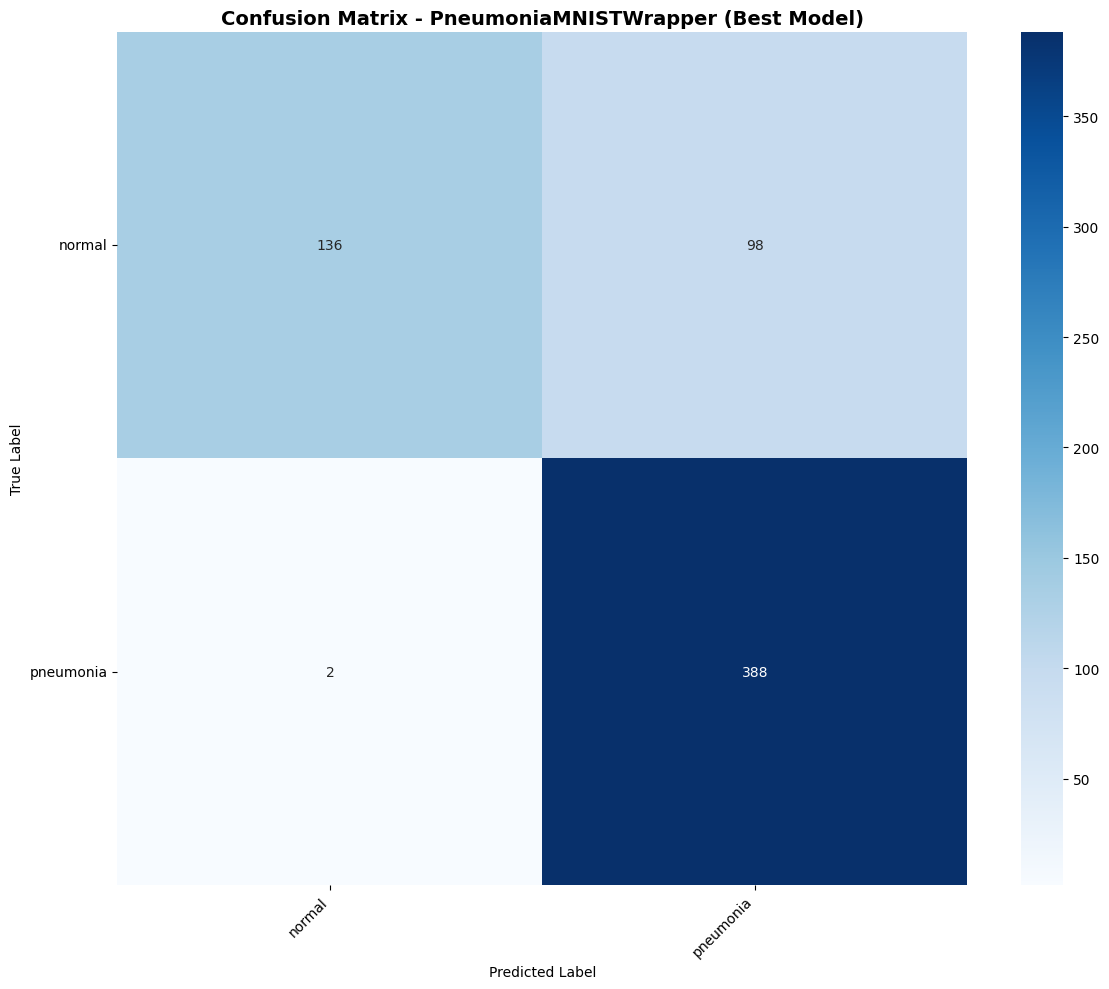

In [30]:
def main():

    # Dataset setup
    batch_size = 32               
    num_workers = 2
    num_epochs = 100
    lr = 1e-4     
    use_focal = True            
    set_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Temporary dataset to compute mean/std
    temp_transform = transforms.Compose([transforms.ToTensor()])
    temp_train = PneumoniaMNISTWrapper(split="train", transform=temp_transform, download=True, size=224)

    print("Computing dataset mean/std from train split...")
    mean, std = compute_mean_std(temp_train, batch_size=batch_size, num_workers=num_workers)
    print(f"Computed mean: {mean}")
    print(f"Computed std : {std}")

    # Define transforms
    base_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # Datasets
    train_dataset = PneumoniaMNISTWrapper(split="train", transform=base_transform, download=True, size=224)
    val_dataset   = PneumoniaMNISTWrapper(split="val",   transform=base_transform, download=True, size=224)
    test_dataset  = PneumoniaMNISTWrapper(split="test",  transform=base_transform, download=True, size=224)

    # Auto-detect classes
    num_classes = len(train_dataset.dataset.info['label'])
    class_names = list(train_dataset.dataset.info['label'].values())
    print(f"Using PneumoniaMNISTWrapper with {num_classes} classes: {class_names}")

    # DataLoaders (standard)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                            shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                             shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f"Total training images: {len(train_dataset)}")
    print(f"Total validation images: {len(val_dataset)}")
    print(f"Total test images: {len(test_dataset)}")

    # Debug sample
    sample_image, sample_target = train_dataset[0]
    print(f"Sample image shape: {sample_image.shape}")
    print(f"Sample target type: {type(sample_target)}, value: {sample_target}")

    # Model (for grayscale)
    model = VisionMambaModel(
        num_classes=num_classes, 
        embed_dim=256, 
        num_layers=3, 
        d_state=16,
        dropblock_prob=0.15,
        input_channels=len(mean) 
    ).to(device)
    
    if torch.cuda.device_count() > 1:
        print("Using", torch.cuda.device_count(), "GPUs!")
        model = nn.DataParallel(model)
    model = model.to(device)

    # Model summary and FLOPs
    print_model_summary(model, input_size=(1, len(mean), 224, 224), device=device.type)
    print_model_flops(model, input_res=(len(mean), 224, 224))

    # Training
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, device, num_epochs=num_epochs, lr=lr, use_focal=use_focal
    )

    plot_training_curves(train_losses, val_losses, train_accs, val_accs)

    # Load best model weights if available
    checkpoint_path = os.path.join("tiny", "best_256_hymacnetv2_Pneumonia.pth")
    if os.path.exists(checkpoint_path):
        print(f"\nLoading best model weights from {checkpoint_path}...")
        model = load_model_weights(model, checkpoint_path)
        print("✓ Best model weights loaded successfully!")
    else:
        print(f"Warning: No checkpoint found at {checkpoint_path}")
        print("Using current model weights for evaluation")

    # Evaluation on test set
    print("\n" + "="*60)
    print("EVALUATING BEST MODEL ON TEST SET")
    print("="*60)

    y_true, y_pred, y_prob, avg_inference_time = evaluate_model(model, test_loader, device)
    metrics = calculate_metrics(y_true, y_pred, y_prob, num_classes=num_classes)

    print("EVALUATION RESULTS")
    print("="*60)
    for k, v in metrics.items():
        print(f"{k.capitalize()}: {v:.4f}")
    print(f"Average Inference Time: {avg_inference_time:.2f} ms/sample")
    print(f"Total Test Samples: {len(y_true)}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - PneumoniaMNISTWrapper (Best Model)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    with open(log_path, "w", encoding="utf-8") as f:
        with redirect_stdout(f):
            main()
